# 03 — Layer 2a: Econometric Baseline
## Pooled OLS · Fixed Effects · Two-Way FE · Random Effects 

### Purpose
Establish an interpretable panel econometric baseline for GDP growth forecasting.
The entity fixed-effects model controls for time-invariant country heterogeneity
and is used as the conservative econometric benchmark against ML and LSTM models.

### Input
- `../data/03_panel_instability.csv`

### Output
- `../data/layer2a_results.csv`
- `layer2a_fe_coefficients.png`
- `layer2a_actual_vs_predicted.png`

### Run after → Run before
`02_instability_index_eda.ipynb` → `04_layer2b_ml_models.ipynb`

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")


TRAIN_END = 2019
COVID_YEARS = [2020, 2021]
TEST_YEARS = [2022, 2023]
OBSERVED_END = 2023

df = pd.read_csv(r"data/03_panel_instability.csv")
df = df.sort_values(["COUNTRY", "YEAR"]).copy()

# Econometric baseline must use observed years only
df = df[df["YEAR"] <= OBSERVED_END].copy()

print(f"Loaded observed panel: {df.shape}")
print(f"Countries: {df['COUNTRY'].nunique()}")
print(f"Years: {df['YEAR'].min()}-{df['YEAR'].max()}")
feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index_lag1",
]

df_model = df.dropna(subset=feature_cols + ["GDP_Growth"]).copy()

print(f"Model panel: {df_model.shape}")
print(f"Features used: {len(feature_cols)}")

Loaded observed panel: (4644, 116)
Countries: 175
Years: 1997-2023
Model panel: (4469, 116)
Features used: 13


In [30]:
train = df_model[df_model["YEAR"] <= TRAIN_END].copy()
test = df_model[df_model["YEAR"].isin(TEST_YEARS)].copy()
covid_test = df_model[df_model["YEAR"].isin(COVID_YEARS)].copy()

def make_panel_xy(data):
    panel = data.set_index(["COUNTRY", "YEAR"]).sort_index()
    X = sm.add_constant(panel[feature_cols], has_constant="add")
    y = panel["GDP_Growth"]
    return panel, X, y

train_panel, X_train, y_train = make_panel_xy(train)
test_panel, X_test, y_test = make_panel_xy(test)
covid_panel, X_covid, y_covid = make_panel_xy(covid_test)

print(f"Train: {train['YEAR'].min()}-{train['YEAR'].max()} | n={len(train)}")
print(f"Test : {test['YEAR'].min()}-{test['YEAR'].max()} | n={len(test)}")
print(f"COVID: {covid_test['YEAR'].min()}-{covid_test['YEAR'].max()} | n={len(covid_test)}")

Train: 1998-2019 | n=3777
Test : 2022-2023 | n=346
COVID: 2020-2021 | n=346


In [31]:
pooled_model = PooledOLS(y_train, X_train).fit(
    cov_type="clustered",
    cluster_entity=True,
)

fe_entity_model = PanelOLS(
    y_train,
    X_train,
    entity_effects=True,
    time_effects=False,
).fit(
    cov_type="clustered",
    cluster_entity=True,
)

re_model = RandomEffects(y_train, X_train).fit(
    cov_type="clustered",
    cluster_entity=True,
)

# Two-way FE is useful for training diagnostics, but not for future-year prediction
# because future/test year effects are not known at prediction time.
fe_twoway_model = PanelOLS(
    y_train,
    X_train,
    entity_effects=True,
    time_effects=True,
).fit(
    cov_type="clustered",
    cluster_entity=True,
)

print("Models fitted successfully")
print(f"Entity FE within R2: {fe_entity_model.rsquared:.4f}")
print(f"Entity FE observations: {int(fe_entity_model.nobs)}")
print(f"Entities: {fe_entity_model.entity_info['total']}")

Models fitted successfully
Entity FE within R2: 0.1150
Entity FE observations: 3777
Entities: 175.0


In [32]:
# ── Hausman test ─────────────────────────────────────────────
def hausman_test(fe_result, re_result):
    fe_params = fe_result.params
    re_params = re_result.params

    common = fe_params.index.intersection(re_params.index)

    b_fe = fe_params.loc[common].values
    b_re = re_params.loc[common].values

    v_fe = fe_result.cov.loc[common, common].values
    v_re = re_result.cov.loc[common, common].values

    diff = b_fe - b_re
    v_diff = v_fe - v_re

    stat = float(diff.T @ np.linalg.pinv(v_diff) @ diff)

    if (not np.isfinite(stat)) or stat < 0:
        return {
            "Hausman_stat": stat,
            "p_value": np.nan,
            "decision": "Inconclusive: covariance difference is not positive semi-definite. Keep entity FE as conservative baseline.",
        }

    p_value = 1 - scipy_stats.chi2.cdf(stat, df=len(common))

    decision = (
        "Reject RE: use entity FE"
        if p_value < 0.05
        else "Do not reject RE, but report entity FE as conservative baseline"
    )

    return {
        "Hausman_stat": stat,
        "p_value": p_value,
        "decision": decision,
    }

hausman_result = hausman_test(fe_entity_model, re_model)

print(f"Hausman statistic: {hausman_result['Hausman_stat']:.4f}")
print(f"P-value: {hausman_result['p_value']}")
print(f"Decision: {hausman_result['decision']}")

Hausman statistic: 77.7181
P-value: 7.480560615391596e-11
Decision: Reject RE: use entity FE


In [33]:
def predict_entity_fe(fe_result, X):
    X_aligned = X.reindex(columns=fe_result.params.index)

    beta_pred = X_aligned @ fe_result.params

    effects = fe_result.estimated_effects.reset_index()

    entity_effect = (
        effects.groupby("COUNTRY")["estimated_effects"]
        .mean()
    )

    country_effect = (
        X_aligned.index.get_level_values("COUNTRY")
        .map(entity_effect)
        .fillna(0)
    )

    return np.asarray(beta_pred) + np.asarray(country_effect)

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(name, y_true, y_pred, period=""):
    """
    Evaluate regression model performance.
    Compatible with all scikit-learn versions.
    """
    yt = np.array(y_true).flatten()
    yp = np.array(y_pred).flatten()

    # Remove any NaN pairs
    mask = ~(np.isnan(yt) | np.isnan(yp))
    yt   = yt[mask]
    yp   = yp[mask]

    return {
        "Model"          : name,
        "Period"         : period,
        "N"              : len(yt),
        "RMSE"           : round(np.sqrt(mean_squared_error(yt, yp)), 3),
        "MAE"            : round(mean_absolute_error(yt, yp), 3),
        "R2"             : round(r2_score(yt, yp), 3),
        "Mean_Actual"    : round(float(yt.mean()), 3),
        "Mean_Predicted" : round(float(yp.mean()), 3),
        "Mean_Error"     : round(float((yt - yp).mean()), 3),
    }

In [35]:
results = []

# Main observed test: 2022-2023
results.append(
    evaluate_model(
        "Pooled OLS",
        y_test,
        pooled_model.predict(exog=X_test).values.flatten(),
        "Observed test (2022-23)",
    )
)

results.append(
    evaluate_model(
        "Entity Fixed Effects",
        y_test,
        predict_entity_fe(fe_entity_model, X_test),
        "Observed test (2022-23)",
    )
)

results.append(
    evaluate_model(
        "Random Effects",
        y_test,
        re_model.predict(exog=X_test).values.flatten(),
        "Observed test (2022-23)",
    )
)

# COVID stress test: 2020-2021
results.append(
    evaluate_model(
        "Pooled OLS",
        y_covid,
        pooled_model.predict(exog=X_covid).values.flatten(),
        "COVID stress test (2020-21)",
    )
)

results.append(
    evaluate_model(
        "Entity Fixed Effects",
        y_covid,
        predict_entity_fe(fe_entity_model, X_covid),
        "COVID stress test (2020-21)",
    )
)

results.append(
    evaluate_model(
        "Random Effects",
        y_covid,
        re_model.predict(exog=X_covid).values.flatten(),
        "COVID stress test (2020-21)",
    )
)

results_df = pd.DataFrame(results)

display(results_df.sort_values(["Period", "RMSE"]))

results_df.to_csv(r"data/layer2a_results.csv", index=False)
print("Saved: data/layer2a_results.csv")

,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
4,Entity Fixed Effects,COVID stress test (2020-21),346,8.953,6.646,-0.154,0.764,2.876,-2.112
3,Pooled OLS,COVID stress test (2020-21),346,9.095,6.780,-0.191,0.764,2.484,-1.719
5,Random Effects,COVID stress test (2020-21),346,9.095,6.780,-0.191,0.764,2.484,-1.719
0,Pooled OLS,Observed test (2022-23),346,4.816,2.755,0.206,3.813,3.296,0.517
2,Random Effects,Observed test (2022-23),346,4.816,2.755,0.206,3.813,3.296,0.517
1,Entity Fixed Effects,Observed test (2022-23),346,4.914,2.698,0.173,3.813,3.639,0.174


Saved: data/layer2a_results.csv


In [36]:
# # ── Period breakdown ─────────────────────────────────────────
# fe_pred = X_test.values @ fe_model.params.values
# eval_df = pd.DataFrame({
#     "COUNTRY"  : test_panel.index.get_level_values("COUNTRY"),
#     "YEAR"     : test_panel.index.get_level_values("YEAR"),
#     "Actual"   : y_test.values,
#     "Predicted": fe_pred,
#     "Error"    : y_test.values - fe_pred
# })

# for years, label in [
#     ([2017,2018,2019],"Pre-COVID"),
#     ([2020],          "COVID shock"),
#     ([2021,2022],     "Recovery"),
#     ([2023,2024,2025,2026],     "Post-COVID"),
# ]:
#     src = train if max(years) <= 2019 else test
#     sub = src[src["YEAR"].isin(years)]
#     X_s = sm.add_constant(sub.set_index(["COUNTRY","YEAR"])[feature_cols])
#     y_s = sub.set_index(["COUNTRY","YEAR"])["GDP_Growth"]
#     p_s = X_s.values @ fe_model.params.values
#     if sub.empty:
#         print(f"{label:<22} SKIPPED — no observations for years {years}")
#         continue
#     r   = evaluate("FE (entity)", y_s.values, p_s, label)
#     print(f"{label:<22} RMSE={r['RMSE']}  MAE={r['MAE']}  R²={r['R2']}")

In [37]:
fe_test_pred = predict_entity_fe(fe_entity_model, X_test)

fe_prediction_df = test_panel.reset_index()[["COUNTRY", "YEAR", "GDP_Growth"]].copy()
fe_prediction_df["FE_Predicted_GDP_Growth"] = fe_test_pred
fe_prediction_df["FE_Error"] = (
    fe_prediction_df["GDP_Growth"]
    - fe_prediction_df["FE_Predicted_GDP_Growth"]
)

fe_prediction_df.to_csv(r"data/layer2a_fe_predictions_2022_2023.csv", index=False)

display(fe_prediction_df.head())
print("Saved: data/layer2a_fe_predictions_2022_2023.csv")

,COUNTRY,YEAR,GDP_Growth,FE_Predicted_GDP_Growth,FE_Error
0,"Afghanistan, Islamic Republic of",2022,-6.240,0.521335,-6.761335
1,"Afghanistan, Islamic Republic of",2023,2.267,-0.383880,2.650880
2,Albania,2022,4.827,5.022628,-0.195628
3,Albania,2023,4.015,5.551808,-1.536808
4,Algeria,2022,3.600,3.140522,0.459478


Saved: data/layer2a_fe_predictions_2022_2023.csv


In [38]:
coef_table = pd.DataFrame({
    "Feature": fe_entity_model.params.index,
    "Coefficient": fe_entity_model.params.values,
    "CI_Lower": fe_entity_model.conf_int()["lower"].values,
    "CI_Upper": fe_entity_model.conf_int()["upper"].values,
    "P_Value": fe_entity_model.pvalues.values,
})

coef_table.to_csv(r"data/layer2a_fe_coefficients.csv", index=False) 

display(coef_table)
print("Saved: data/layer2a_fe_coefficients.csv")


,Feature,Coefficient,CI_Lower,CI_Upper,P_Value
0,const,2.007340,0.830646,3.184034,0.000832
1,GDP_Growth_lag1,0.018748,-0.125023,0.162519,0.798221
2,GDP_Growth_rollmean3,0.335007,0.059760,0.610253,0.017070
3,Inflation_lag1_log,-0.508297,-0.802578,-0.214016,0.000716
4,Exports_lag1,-0.019468,-0.039490,0.000554,0.056678
5,Imports_lag1,0.027235,0.011000,0.043470,0.001015
6,Fiscal_Balance_lag1,-0.019010,-0.070027,0.032007,0.465083
7,Current_Account_lag1,-0.005335,-0.043708,0.033038,0.785190
8,Debt_diff_lag1,-0.019882,-0.041352,0.001588,0.069517
9,Expenditure_diff_lag1,-0.074371,-0.172312,0.023570,0.136631


Saved: data/layer2a_fe_coefficients.csv


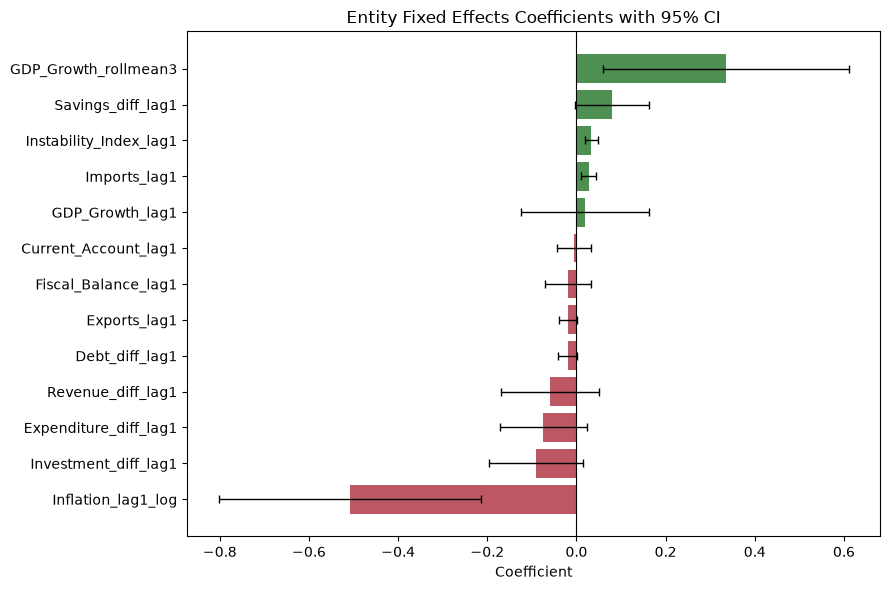

Saved: outputs/layer2a_fe_coefficients.png


In [39]:
plot_df = coef_table[coef_table["Feature"] != "const"].copy()
plot_df = plot_df.sort_values("Coefficient")

plt.figure(figsize=(9, 6))

colors = np.where(plot_df["Coefficient"] >= 0, "#2E7D32", "#B23A48")

plt.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors, alpha=0.85)

plt.errorbar(
    plot_df["Coefficient"],
    plot_df["Feature"],
    xerr=[
        plot_df["Coefficient"] - plot_df["CI_Lower"],
        plot_df["CI_Upper"] - plot_df["Coefficient"],
    ],
    fmt="none",
    color="black",
    linewidth=1,
    capsize=3,
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Entity Fixed Effects Coefficients with 95% CI")
plt.xlabel("Coefficient")
plt.tight_layout()

plt.savefig("layer2a_fe_coefficients.png", dpi=150)
plt.show()

print("Saved: outputs/layer2a_fe_coefficients.png")